### Settings

In [ ]:
COLAB = True

In [2]:
import os
import shutil

In [3]:
if COLAB:
    from google.colab import drive
    
    if os.path.exists("/content/drive"):
        print("Google Drive has already mounted.")
    else:        
        drive.mount('/content/drive')
        print("Google Drive is mounted")

    shutil.copytree("./drive/MyDrive/LLM_from_scratch/", "./", dirs_exist_ok=True);
else:
    print("Running locally, not mounting Google Drive.")

Mounted at /content/drive
Google Drive is mounted


In [4]:
import torch
import torch.nn as nn
import tiktoken

import previous_chapters as prv

#### Data loaders

In [5]:
tokenizer = tiktoken.get_encoding('gpt2')

In [6]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [7]:
filepath = 'the-verdict.txt' if COLAB else '../../data/the-verdict.txt'

with open(filepath,'r', encoding='utf-8') as f:
    text_data = f.read()

tokens = tokenizer.encode(text_data)

len(text_data), len(tokens)

(20479, 5145)

In [8]:
train_ratio = 0.9

split_idx = int(len(text_data) * train_ratio)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [9]:
torch.manual_seed(123)

train_loader = prv.create_dataloader_v1(
    txt=train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    shuffle=True,
    drop_last=True
)

val_loader = prv.create_dataloader_v1(
    txt=val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    shuffle=True,
    drop_last=True
)

In [10]:
for i, (x,y) in enumerate(train_loader, 1):
    print(f'{i}. X shape: {x.shape}, Y shape: {y.shape}')

1. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
2. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
3. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
4. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
5. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
6. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
7. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
8. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])
9. X shape: torch.Size([2, 256]), Y shape: torch.Size([2, 256])


#### Model

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [13]:
torch.manual_seed(123)

model = prv.GPTModel(GPT_CONFIG_124M)
model.to(device)
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

### 5.2 Training an LLM (Colab GPU server)

In [15]:
print(torch.__version__)
torch.cuda.is_available()

2.10.0+cpu


False

In [16]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits_batch = model(input_batch)

    loss = nn.functional.cross_entropy(
        logits_batch.flatten(0,1),
        target_batch.flatten()
        )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    if len(data_loader) == 0:
        return float("nan")
    
    num_batches = min(num_batches, len(data_loader)) if num_batches else len(data_loader)

    total_loss = 0
    for i, (x_batch, y_batch) in enumerate(data_loader):
        if i < num_batches:
            batch_loss = calc_loss_batch(x_batch, y_batch, model, device)
            total_loss += batch_loss
        else:
            break

    return total_loss / num_batches


def text_to_token_ids(text: str, tokenizer) -> torch.tensor:    
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    return torch.tensor(encoded).unsqueeze(0)   # batch dimehsion added


def token_ids_to_text(token_ids: torch.tensor, tokenizer) -> str:
    ids_list =  token_ids.squeeze(0).tolist()  # batch dim removed
    return tokenizer.decode(ids_list)

In [17]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

    model.train()

    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = prv.generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size=context_size
            )
    gen_text = token_ids_to_text(token_ids, tokenizer)
    print(gen_text.replace('\n', ' '))

    model.train()


def train_model_simple(model,
                       train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter,
                       start_context, tokenizer):

    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model,train_loader, val_loader, device, eval_iter)
                
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                      )

        generate_and_print_sample(model, tokenizer, device, start_context)


    return train_losses, val_losses, track_tokens_seen

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [18]:
%%time
torch.manual_seed(123)

model = prv.GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 0.0004,
    weight_decay = 0.1)

num_epochs = 10
train_losses, val_losses, track_tokens_seen = \
    train_model_simple(
        model,train_loader, val_loader,
        optimizer, device,
        num_epochs=num_epochs,
        eval_freq=5, 
        eval_iter=5,
        start_context="Every effort moves you",
        tokenizer=tokenizer)


Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 7.920, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.585, Val loss 7.046
Ep 2 (Step 000015): Train loss 5.984, Val loss 6.598
Every effort moves you, the, and, the, the, the, and, the. ", the,,, the, and, the,, the,, the, and, the, the,, the, and,,,,, the
Ep 3 (Step 000020): Train loss 15.871, Val loss 15.947
Ep 3 (Step 000025): Train loss 5.578, Val loss 6.453
Every effort moves you. Gis. Gis. Gis. Gis. G. I had to----, and--. I had to--. I had. I had to the his--. I had the to the ", and I had.
Ep 4 (Step 000030): Train loss 5.009, Val loss 6.335
Ep 4 (Step 000035): Train loss 4.767, Val loss 6.249
Every effort moves you, and I had been the, I had to the picture. ", I had been--I, I had been the to the of the, I had the to the, I had been, I had the picture. ", I
Ep 5 (Step 000040): Train loss 4.222, Val loss 6.236
Every effort

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

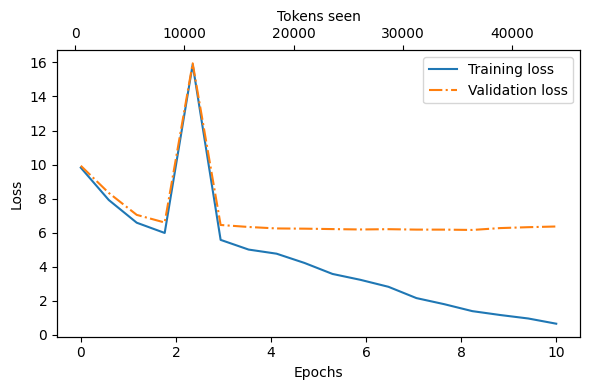

In [20]:

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(6, 4))

    # Move losses to CPU if they are on GPU to avoid issues with plotting
    train_losses = [loss.cpu() for loss in train_losses if loss.device != 'cpu']
    val_losses = [loss.cpu() for loss in val_losses if loss.device != 'cpu']

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    # plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

### 5.3 Decoding strategies to control randomness

In [21]:
if device != "cpu":
    model.to("cpu")

model.eval();

In [22]:
token_ids = prv.generate_text_simple(
    model=model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




#### 5.3.1 Temperature scaling

In [23]:
vocab = {
 "closer": 0,
 "every": 1,
 "effort": 2,
 "forward": 3,
 "inches": 4,
 "moves": 5,
 "pizza": 6,
 "toward": 7,
 "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [24]:
probas = torch.softmax(next_token_logits, dim=0)
probas

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

In [25]:
next_word_idx = torch.argmax(probas)
next_word = inverse_vocab[next_word_idx.item()]

next_word

'forward'

In [26]:
torch.manual_seed(123)
nw_idx = torch.multinomial(probas, num_samples=1).item()
nw_idx, inverse_vocab[nw_idx]

(3, 'forward')

In [27]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample_ids = torch.tensor(
        [torch.multinomial(probas, num_samples=1).item() for _ in range(1000)]
    )

    for i, cnt in enumerate(torch.bincount(sample_ids)):
        print(f'{inverse_vocab[i]}: {cnt}')


print_sampled_tokens(probas)

closer: 73
every: 0
effort: 0
forward: 582
inches: 2
moves: 0
pizza: 0
toward: 343


In [28]:
def softmax_with_temperature(logits, temperature):
    return torch.softmax(logits / temperature, dim=0)

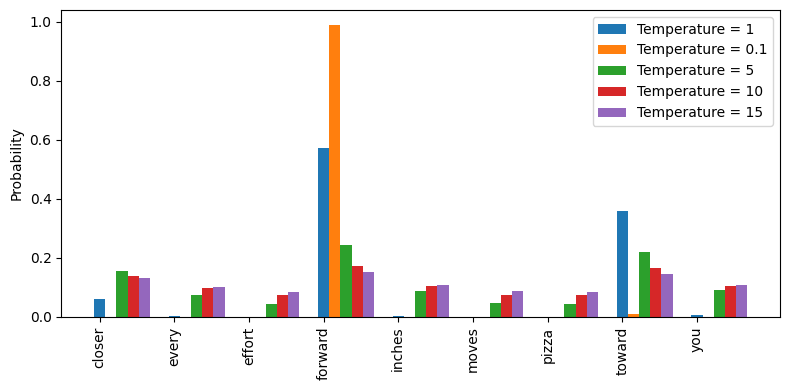

In [29]:
temperatures = [1, 0.1, 5, 10, 15] 

scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(8, 4))
for i, T in enumerate(temperatures):
 rects = ax.bar(x + i * bar_width, scaled_probas[i],
 bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show();

##### Exercise 5.1

In [30]:
temperatures = [1, 0.1, 5, 10, 15] 

for T in temperatures:
    scaled_probas = torch.softmax(next_token_logits / T, dim=0)
    print(f'{T = }')
    print_sampled_tokens(scaled_probas)
    print('-' * 10, '\n')


T = 1
closer: 73
every: 0
effort: 0
forward: 582
inches: 2
moves: 0
pizza: 0
toward: 343
---------- 

T = 0.1
closer: 0
every: 0
effort: 0
forward: 985
inches: 0
moves: 0
pizza: 0
toward: 15
---------- 

T = 5
closer: 165
every: 75
effort: 42
forward: 239
inches: 71
moves: 46
pizza: 32
toward: 227
you: 103
---------- 

T = 10
closer: 137
every: 107
effort: 69
forward: 176
inches: 79
moves: 83
pizza: 63
toward: 172
you: 114
---------- 

T = 15
closer: 128
every: 110
effort: 85
forward: 163
inches: 83
moves: 92
pizza: 79
toward: 149
you: 111
---------- 



#### 5.3.2 Top-k sampling

In [31]:
next_token_logits

tensor([ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300, -1.6200, -1.8900,  6.2800,
         1.7900])

In [32]:
top_k = 3

topk = torch.topk(next_token_logits, top_k)
topk

torch.return_types.topk(
values=tensor([6.7500, 6.2800, 4.5100]),
indices=tensor([3, 7, 0]))

In [33]:
# mask out logits not in top-k
mask = torch.ones_like(next_token_logits, dtype=torch.bool)
mask[topk.indices] = False
new_logits = next_token_logits.clone()
new_logits[mask] = float('-inf')

new_logits

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [34]:
mask

tensor([False,  True,  True, False,  True,  True,  True, False,  True])

In [35]:
new_probas = torch.softmax(new_logits, dim=0)
new_probas

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

#### 5.3.3 Modifying the text generation function

In [36]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # top-k sampling
        if top_k:
            tk_idx = torch.topk(logits, top_k).indices
            mask = torch.ones_like(logits, dtype=torch.bool)
            mask[torch.arange(len(tk_idx)).unsqueeze(1), tk_idx] = False
            logits[mask] = float('-inf')

        # top-p scaling
        if temperature > 0:
            probas = torch.softmax(logits / temperature, dim=-1)
            idx_next = torch.multinomial(probas, num_samples=1)   # (batch, 1)
        else:
            # Greedy sampling:
            # get the idx of the vocab entry with the highest logits value
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        if idx_next == eos_id:
            break

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [37]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

" surprise, a--because he knew me by his knees


In [38]:
logits = torch.rand(3,6)
logits

tensor([[0.3648, 0.1138, 0.9045, 0.0620, 0.6105, 0.3526],
        [0.9539, 0.9829, 0.1890, 0.4702, 0.1957, 0.1999],
        [0.6856, 0.7082, 0.6550, 0.2678, 0.6249, 0.7777]])

In [39]:
tk = torch.topk(logits, 3)
tk.indices

tensor([[2, 4, 0],
        [1, 0, 3],
        [5, 1, 0]])

In [40]:
# mask out logits not in top-k
mask = torch.ones_like(logits, dtype=torch.bool)
mask[torch.arange(len(tk.indices)).unsqueeze(1), tk.indices] = False
mask


tensor([[False,  True, False,  True, False,  True],
        [False, False,  True, False,  True,  True],
        [False, False,  True,  True,  True, False]])

In [41]:
new_logits = logits.clone()
new_logits[mask] = float('-inf')

new_logits

tensor([[0.3648,   -inf, 0.9045,   -inf, 0.6105,   -inf],
        [0.9539, 0.9829,   -inf, 0.4702,   -inf,   -inf],
        [0.6856, 0.7082,   -inf,   -inf,   -inf, 0.7777]])

### 5.4 Loading and saving model weights in PyTorch

In [ ]:
# Saving
torch.save({
    'model_state': model.state_dict(),
    'optimizer' : optimizer.state_dict()
}, "model_optim.pth"
)

In [44]:
! du -Sh model_optim.pth

1.9G	model_optim.pth


In [45]:
# Loading the saved states
checkpoint = torch.load("model_optim.pth", map_location=device)

model = prv.GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint['model_state'])

opimizer = torch.optim.AdamW(model.parameters(), lr=5e-04, weight_decay=0.1)
optimizer.load_state_dict(checkpoint['optimizer'])

In [ ]:
# ! cp ./model_optim.pth ./drive/MyDrive/LLM_from_scratch/

#### Exercise 5.4

In [12]:
device = "cpu"

In [13]:
saved_params = torch.load("model_optim.pth", map_location=device)                    

In [14]:
model = prv.GPTModel(GPT_CONFIG_124M)
model.load_state_dict(saved_params['model_state'])

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-04, weight_decay=0.1)
optimizer.load_state_dict(saved_params['optimizer'])

In [21]:
train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=1,
    start_context="Every effort moves you",
    eval_freq=5,
    eval_iter=5,
    tokenizer=tokenizer
    )

Ep 1 (Step 000000): Train loss 0.532, Val loss 6.441
Ep 1 (Step 000005): Train loss 0.369, Val loss 6.462
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back the window-curtains, and I turned, and down the room, stopping now


([tensor(0.5322), tensor(0.3694)],
 [tensor(6.4409), tensor(6.4621)],
 [512, 3072])